# 📊 Análisis Exploratorio de Datos (EDA)

El objetivo de este proyecto es analizar un dataset de marketing bancario para identificar los factores que influyen en la suscripción de los clientes a un producto financiero.

1. CARGA DE LIBRERÍAS

In [1]:
import numpy as np
import pandas as pd
import openpyxl as xc
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

2. CARGA DE DATOS

## 📥 Carga de datos

Se cargan los distintos archivos disponibles, incluyendo el dataset principal en formato CSV y las tablas adicionales en formato Excel.

In [2]:
# CSV principal
bank_account = pd.read_csv(r"C:\Users\vanes\OneDrive\Escritorio\Python for Data\bank-additional.csv")

# Excel con múltiples hojas
account_additional = pd.read_excel(r"C:\Users\vanes\OneDrive\Escritorio\Python for Data\customer-details.xlsx", sheet_name=None)

acc_2012 = account_additional["2012"]
acc_2013 = account_additional["2013"]
acc_2014 = account_additional["2014"]

3. EXPLORACIÓN INICIAL DEL DATASET PRINCIPAL

## 🔍 Exploración inicial

Se realiza un análisis preliminar de los datos para entender su estructura, tipos de variables, presencia de valores nulos y posibles duplicados.

In [3]:
bank_account.head()

,Unnamed: 0,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_
0,0,NaN,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,1,999,0,NONEXISTENT,1.1,"93,994","-36,4","4,857",5191,no,2-agosto-2019,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079
1,1,57.0,services,MARRIED,high.school,NaN,0.0,0.0,telephone,149,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,14-septiembre-2016,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097
2,2,37.0,services,MARRIED,high.school,0.0,1.0,0.0,telephone,226,1,999,0,NONEXISTENT,1.1,"93,994","-36,4","4,857",5191,no,15-febrero-2019,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,3,40.0,admin.,MARRIED,basic.6y,0.0,0.0,0.0,telephone,151,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,29-noviembre-2015,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e
4,4,56.0,services,MARRIED,high.school,0.0,0.0,1.0,telephone,307,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,29-enero-2017,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


In [4]:
bank_account.shape

(43000, 24)

In [5]:
bank_account.info()

<class 'pandas.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      43000 non-null  int64  
 1   age             37880 non-null  float64
 2   job             42655 non-null  str    
 3   marital         42915 non-null  str    
 4   education       41193 non-null  str    
 5   default         34019 non-null  float64
 6   housing         41974 non-null  float64
 7   loan            41974 non-null  float64
 8   contact         43000 non-null  str    
 9   duration        43000 non-null  int64  
 10  campaign        43000 non-null  int64  
 11  pdays           43000 non-null  int64  
 12  previous        43000 non-null  int64  
 13  poutcome        43000 non-null  str    
 14  emp.var.rate    43000 non-null  float64
 15  cons.price.idx  42529 non-null  str    
 16  cons.conf.idx   43000 non-null  str    
 17  euribor3m       33744 non-null  str    
 1

In [6]:
bank_account.describe()

,Unnamed: 0,age,default,housing,loan,duration,campaign,pdays,previous,emp.var.rate,latitude,longitude
count,43000.000000,37880.000000,34019.000000,41974.000000,41974.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000
mean,20651.099047,39.977112,0.000088,0.535998,0.155620,257.739279,2.567233,962.330953,0.174023,0.077128,36.856697,-95.939067
std,11868.770913,10.437957,0.009390,0.498708,0.362499,258.666033,2.772294,187.260394,0.497366,1.573898,7.225948,16.752282
min,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,24.396000,-124.997000
25%,10381.750000,32.000000,0.000000,0.000000,0.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,30.614750,-110.494250
50%,20642.500000,38.000000,0.000000,1.000000,0.000000,179.000000,2.000000,999.000000,0.000000,1.100000,36.761000,-95.899500
75%,30930.250000,47.000000,0.000000,1.000000,0.000000,319.000000,3.000000,999.000000,0.000000,1.400000,43.113250,-81.427750
max,41187.000000,98.000000,1.000000,1.000000,1.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,49.384000,-66.937000


4. LIMPIEZA BÁSICA DEL CSV

## 🧹 Limpieza superficial de datos

En esta fase se procede a:

- tratar valores nulos
- comprobar la existencia de valores duplicados

In [7]:
# Nulos
bank_account.isnull().sum()

Unnamed: 0           0
age               5120
job                345
marital             85
education         1807
default           8981
housing           1026
loan              1026
contact              0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx     471
cons.conf.idx        0
euribor3m         9256
nr.employed          0
y                    0
date               248
latitude             0
longitude            0
id_                  0
dtype: int64

In [8]:
# Duplicados
bank_account.duplicated().sum()

np.int64(0)

5. PREPARACIÓN DE LOS DATOS DEL EXCEL

En esta fase se procede a:

- añadir las columnas correspondientes a cada año reflejadas en las hojas del excel inicial

In [9]:
# Añadir columna de año
acc_2012["year"] = 2012
acc_2013["year"] = 2013
acc_2014["year"] = 2014

6. UNIFICACIÓN DE LAS HOJAS DEL EXCEL

En esta fase se procede a:

- reunir en una única tabla los datos de las 3 hojas de excel

In [10]:
clientes_year = pd.concat([acc_2012, acc_2013, acc_2014], ignore_index=True)

In [11]:
clientes_year.head()

,Columna 1,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID,year
0,0,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079,2012
1,1,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097,2012
2,2,147233,1,1,2012-02-02,5,3f9f49b5-e410-4948-bf6e-f9244f04918b,2012
3,3,121393,1,2,2012-12-21,29,9991fafb-4447-451a-8be2-b0df6098d13e,2012
4,4,63164,1,2,2012-06-20,20,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,2012


In [12]:
clientes_year.info()

<class 'pandas.DataFrame'>
RangeIndex: 43170 entries, 0 to 43169
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Columna 1          43170 non-null  int64         
 1   Income             43170 non-null  int64         
 2   Kidhome            43170 non-null  int64         
 3   Teenhome           43170 non-null  int64         
 4   Dt_Customer        43170 non-null  datetime64[us]
 5   NumWebVisitsMonth  43170 non-null  int64         
 6   ID                 43170 non-null  str           
 7   year               43170 non-null  int64         
dtypes: datetime64[us](1), int64(6), str(1)
memory usage: 2.6 MB


7. NORMALIZACIÓN DE COLUMNAS CLAVE

en esta fase se procede a:

- unificar nombre de las claves

In [13]:
bank_account = bank_account.rename(columns={"id_": "id"})
clientes_year = clientes_year.rename(columns={"ID": "id"})

8. UNIÓN DE DATASETS (MERGE)

## 🔗 Integración de datos

Se combinan los distintos datasets utilizando el identificador de cliente, generando un único dataset final (`bank_final`).

In [14]:
bank_final = bank_account.merge(clientes_year, on="id", how="left")

9. LIMPIEZA FINAL

## 🧹 Limpieza y preparación de datos

En esta fase se procede a:

- eliminar columnas irrelevantes
- transformar variables
- renombrar columnas

El objetivo es obtener un dataset limpio y consistente para el análisis.

In [15]:
bank_final = bank_final.drop(columns=["Unnamed: 0", "Columna 1"], errors="ignore")
bank_final = bank_final.drop(columns=["default"])
bank_final = bank_final.drop(columns=["nr.employed"])
bank_final = bank_final.drop(columns=["cons.conf.idx"])
bank_final = bank_final.drop(columns=["cons.price.idx"])
bank_final = bank_final.drop(columns=["euribor3m"])

In [16]:
# Convertir fecha
bank_final["Dt_Customer"] = pd.to_datetime(bank_final["Dt_Customer"], dayfirst=True)

In [17]:
# Convertir año
bank_final["year"] = bank_final["year"].astype("category")

In [18]:
cols_binarias = ["housing", "loan"]

for col in cols_binarias:
    bank_final[col] = bank_final[col].map({1: "Yes", 0: "No"})

In [19]:
for col in cols_binarias:
    bank_final[col] = bank_final[col].astype("category")

In [20]:
bank_final = bank_final.rename(columns={"y": "subscription"})

10. VERIFICACIÓN FINAL DEL DATASET

Comprobación final de los datos previo al análisis

In [21]:
bank_final.head()

,age,job,marital,education,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,subscription,date,latitude,longitude,id,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,year
0,NaN,housemaid,MARRIED,basic.4y,No,No,telephone,261,1,999,0,NONEXISTENT,1.1,no,2-agosto-2019,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079,161770,1,0,2012-04-04,29,2012
1,57.0,services,MARRIED,high.school,No,No,telephone,149,1,999,0,NONEXISTENT,1.1,no,14-septiembre-2016,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097,85477,1,1,2012-12-30,7,2012
2,37.0,services,MARRIED,high.school,Yes,No,telephone,226,1,999,0,NONEXISTENT,1.1,no,15-febrero-2019,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b,147233,1,1,2012-02-02,5,2012
3,40.0,admin.,MARRIED,basic.6y,No,No,telephone,151,1,999,0,NONEXISTENT,1.1,no,29-noviembre-2015,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e,121393,1,2,2012-12-21,29,2012
4,56.0,services,MARRIED,high.school,No,Yes,telephone,307,1,999,0,NONEXISTENT,1.1,no,29-enero-2017,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,63164,1,2,2012-06-20,20,2012


In [22]:
bank_final.shape

(43000, 24)

In [23]:
bank_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   age                37880 non-null  float64       
 1   job                42655 non-null  str           
 2   marital            42915 non-null  str           
 3   education          41193 non-null  str           
 4   housing            41974 non-null  category      
 5   loan               41974 non-null  category      
 6   contact            43000 non-null  str           
 7   duration           43000 non-null  int64         
 8   campaign           43000 non-null  int64         
 9   pdays              43000 non-null  int64         
 10  previous           43000 non-null  int64         
 11  poutcome           43000 non-null  str           
 12  emp.var.rate       43000 non-null  float64       
 13  subscription       43000 non-null  str           
 14  date             

In [24]:
bank_final.isnull().sum().sort_values(ascending=False)

age                  5120
education            1807
housing              1026
loan                 1026
job                   345
date                  248
marital                85
latitude                0
NumWebVisitsMonth       0
Dt_Customer             0
Teenhome                0
Kidhome                 0
Income                  0
id                      0
longitude               0
emp.var.rate            0
subscription            0
poutcome                0
previous                0
pdays                   0
campaign                0
duration                0
contact                 0
year                    0
dtype: int64

In [25]:
bank_final.duplicated().sum()

np.int64(0)

In [26]:
bank_final.select_dtypes(include="number").describe().round(2)

,age,duration,campaign,pdays,previous,emp.var.rate,latitude,longitude,Income,Kidhome,Teenhome,NumWebVisitsMonth
count,37880.00,43000.00,43000.00,43000.00,43000.00,43000.00,43000.00,43000.00,43000.00,43000.00,43000.00,43000.00
mean,39.98,257.74,2.57,962.33,0.17,0.08,36.86,-95.94,93241.20,1.00,1.00,16.59
std,10.44,258.67,2.77,187.26,0.50,1.57,7.23,16.75,50498.32,0.82,0.82,9.24
min,17.00,0.00,1.00,0.00,0.00,-3.40,24.40,-125.00,5841.00,0.00,0.00,1.00
25%,32.00,102.00,1.00,999.00,0.00,-1.80,30.61,-110.49,49610.00,0.00,0.00,9.00
50%,38.00,179.00,2.00,999.00,0.00,1.10,36.76,-95.90,93050.50,1.00,1.00,17.00
75%,47.00,319.00,3.00,999.00,0.00,1.40,43.11,-81.43,136744.50,2.00,2.00,25.00
max,98.00,4918.00,56.00,999.00,7.00,1.40,49.38,-66.94,180802.00,2.00,2.00,32.00


11. ANÁLISIS UNIVARIADO

## 📊 Análisis univariado

Se analiza cada variable de forma individual para comprender su distribución, detectar valores atípicos y evaluar su comportamiento.

11.1 SEPARAR VARIABLES

In [27]:
numericas = bank_final.select_dtypes(include="number")
numericas.head()

,age,duration,campaign,pdays,previous,emp.var.rate,latitude,longitude,Income,Kidhome,Teenhome,NumWebVisitsMonth
0,NaN,261,1,999,0,1.1,41.495,-71.233,161770,1,0,29
1,57.0,149,1,999,0,1.1,34.601,-83.923,85477,1,1,7
2,37.0,226,1,999,0,1.1,34.939,-94.847,147233,1,1,5
3,40.0,151,1,999,0,1.1,49.041,-70.308,121393,1,2,29
4,56.0,307,1,999,0,1.1,38.033,-104.463,63164,1,2,20


In [28]:
categoricas = bank_final.select_dtypes(include=["object", "category"])
categoricas.head()

C:\Users\vanes\AppData\Local\Temp\ipykernel_9740\3515007159.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = bank_final.select_dtypes(include=["object", "category"])


,job,marital,education,housing,loan,contact,poutcome,subscription,date,id,year
0,housemaid,MARRIED,basic.4y,No,No,telephone,NONEXISTENT,no,2-agosto-2019,089b39d8-e4d0-461b-87d4-814d71e0e079,2012
1,services,MARRIED,high.school,No,No,telephone,NONEXISTENT,no,14-septiembre-2016,e9d37224-cb6f-4942-98d7-46672963d097,2012
2,services,MARRIED,high.school,Yes,No,telephone,NONEXISTENT,no,15-febrero-2019,3f9f49b5-e410-4948-bf6e-f9244f04918b,2012
3,admin.,MARRIED,basic.6y,No,No,telephone,NONEXISTENT,no,29-noviembre-2015,9991fafb-4447-451a-8be2-b0df6098d13e,2012
4,services,MARRIED,high.school,No,Yes,telephone,NONEXISTENT,no,29-enero-2017,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,2012


11.2. VARIABLES NUMÉRICAS

In [29]:
numericas.describe().round(2)

,age,duration,campaign,pdays,previous,emp.var.rate,latitude,longitude,Income,Kidhome,Teenhome,NumWebVisitsMonth
count,37880.00,43000.00,43000.00,43000.00,43000.00,43000.00,43000.00,43000.00,43000.00,43000.00,43000.00,43000.00
mean,39.98,257.74,2.57,962.33,0.17,0.08,36.86,-95.94,93241.20,1.00,1.00,16.59
std,10.44,258.67,2.77,187.26,0.50,1.57,7.23,16.75,50498.32,0.82,0.82,9.24
min,17.00,0.00,1.00,0.00,0.00,-3.40,24.40,-125.00,5841.00,0.00,0.00,1.00
25%,32.00,102.00,1.00,999.00,0.00,-1.80,30.61,-110.49,49610.00,0.00,0.00,9.00
50%,38.00,179.00,2.00,999.00,0.00,1.10,36.76,-95.90,93050.50,1.00,1.00,17.00
75%,47.00,319.00,3.00,999.00,0.00,1.40,43.11,-81.43,136744.50,2.00,2.00,25.00
max,98.00,4918.00,56.00,999.00,7.00,1.40,49.38,-66.94,180802.00,2.00,2.00,32.00


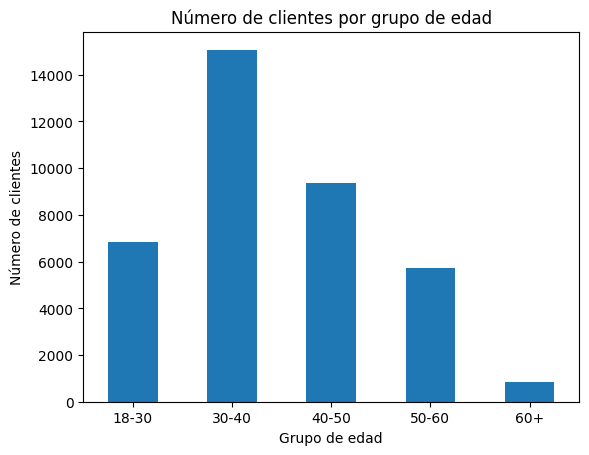

In [48]:
bank_final["age_group"].value_counts().sort_index().plot(kind="bar")

plt.title("Número de clientes por grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Número de clientes")
plt.xticks(rotation=0)
plt.show()

En este gráfico se puede apreciar con mucha claridad que el grupo de edad que comprende los 30-40 años es el que cuenta con más número de clientes con respecto al segundo grup (40-50). A destacar, los grupos de edad con menor número de clientes corresponden a los de mayor edad (50-60 y 60+)

In [54]:
bank_final["income_group"] = pd.cut(
    bank_final["Income"],
    bins=[0, 20000, 40000, 60000, 80000, 100000, 200000],
    labels=["<20k", "20-40k", "40-60k", "60-80k", "80-100k", "100k+"]
)

Consideré oportuno agrupar los datos relaciones con "Income" debido a la gran cantidad de datos que contiene (los gráficos quedaban demasiado saturados o no aportaban una información clara). Por este motivo agrupé los ingresos para que el gráfico fuera más legible, al igual que con las edades del gráfico anterior.

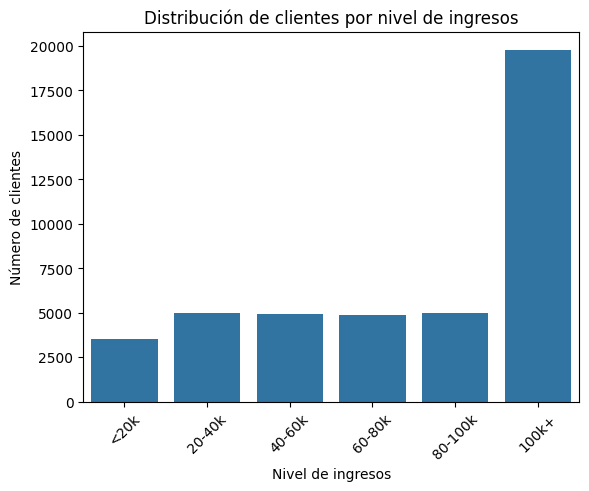

In [55]:
sns.countplot(x="income_group", data=bank_final)
plt.title("Distribución de clientes por nivel de ingresos")
plt.xlabel("Nivel de ingresos")
plt.ylabel("Número de clientes")
plt.xticks(rotation=45)
plt.show()

En este gráfico se puede observar que la gran mayoría de los clientes están agrupados en la categoría (100k+), viendo también que la zona media del gráfico está muy equilibrada, siendo la categoría (>20k) la que cuenta con un menor número de clientes.

11.3. VARIABLES CATEGÓRICAS

In [32]:
categoricas.describe()

,job,marital,education,housing,loan,contact,poutcome,subscription,date,id,year
count,42655,42915,41193,41974,41974,43000,43000,43000,42752,43000,43000
unique,11,3,7,2,2,2,3,2,1825,43000,3
top,admin.,MARRIED,university.degree,Yes,No,cellular,NONEXISTENT,no,28-febrero-2018,089b39d8-e4d0-461b-87d4-814d71e0e079,2012
freq,10873,25999,12722,22498,35442,27396,37103,38156,95,1,20018


In [33]:
bank_final["subscription"].value_counts()

subscription
no     38156
yes     4844
Name: count, dtype: int64

In [34]:
bank_final["subscription"].value_counts(normalize=True)

subscription
no     0.887349
yes    0.112651
Name: proportion, dtype: float64

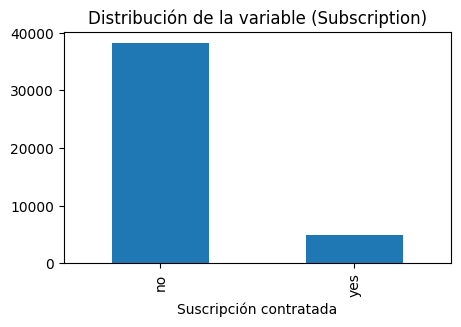

In [60]:
bank_final["subscription"].value_counts().plot(kind="bar", figsize=(5,3))
plt.title("Distribución de la variable (Subscription)")
plt.xlabel ("Suscripción contratada")
plt.show()

Se puede observar en este gráfico que la tasa de clientes que no se han suscrito a ningún producto o servicio es notablemente mayor a la tasa de los que sí lo han hecho.

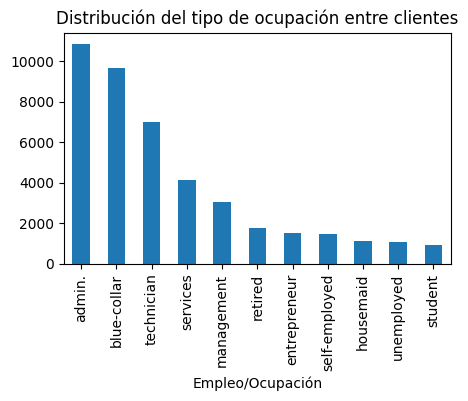

In [58]:
bank_final["job"].value_counts().plot(kind="bar", figsize=(5,3))
plt.title("Distribución del tipo de ocupación entre clientes")
plt.xlabel("Empleo/Ocupación")
plt.show()

En este gráfico observamos cómo existe una gran diferencia en las distintas ocupaciones de los clientes del banco: siendo el grupo de estudiantes, desempleados y amas de casa los que cuentan con un número menor (lo que resulta bastante lógico debido a que son grupos que cuentan con menos ingresos) y siendo el grupo de personal administrativo el que cuenta con mayor número de clientes.

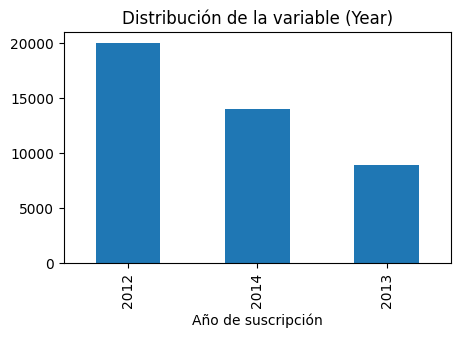

In [61]:
bank_final["year"].value_counts().plot(kind="bar", figsize=(5,3))
plt.title("Distribución de la variable (Year)")
plt.xlabel("Año de suscripción")
plt.show()

Se puede observar en este gráfico que hay una diferencia bastante notable de captación de clientes en el año 2012 con respeto a 2014 y 2013.

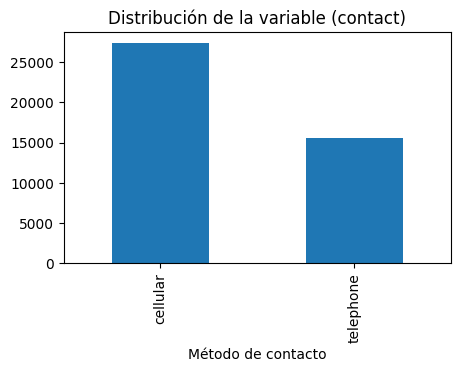

In [62]:
bank_final["contact"].value_counts().plot(kind="bar", figsize=(5,3))
plt.title("Distribución de la variable (contact)")
plt.xlabel("Método de contacto")
plt.show()

En este gráfico se aprecia que el número de contactos a través de teléfono móvil fue bastante mayor que los realizados por medio de teléfono fijo.

12. ANÁLISIS BIVARIADO

## 🔗 Análisis bivariado

Se estudia la relación entre las variables independientes y la variable objetivo (`subscription`) con el fin de identificar patrones relevantes.

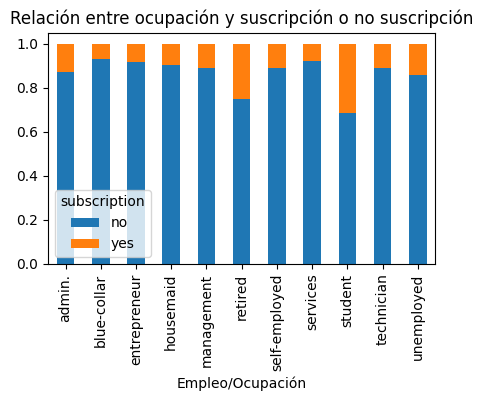

In [63]:
pd.crosstab(bank_final["job"], bank_final["subscription"], normalize="index").plot(kind="bar", stacked=True, figsize=(5,3))
plt.title("Relación entre ocupación y suscripción o no suscripción")
plt.xlabel("Empleo/Ocupación")
plt.show()

Se observan diferencias en la tasa de suscripción entre los distintos perfiles profesionales. Algunas categorías presentan una mayor proporción de clientes que contratan el producto, lo que sugiere que la ocupación puede influir en el comportamiento del cliente. Destacan notablemente los datos relacionados a 'student' (categoría que reflejaba el número más bajo en el gráfico relacionado a la categoría 'job') y 'retired'.

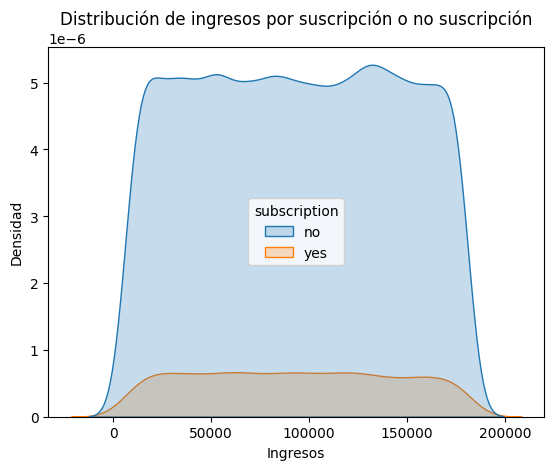

In [67]:
sns.kdeplot(data=bank_final, x="Income", hue="subscription", fill=True,)
plt.title("Distribución de ingresos por suscripción o no suscripción")
plt.xlabel("Ingresos")
plt.ylabel("Densidad")
plt.show()

Se aprecia una ligera diferencia en la distribución de ingresos entre los clientes que suscriben y los que no. Aunque existe cierto solapamiento, los clientes con mayores ingresos tienden a presentar una mayor probabilidad de suscripción.

In [42]:
bank_final["age_group"] = pd.cut(
    bank_final["age"],
    bins=[18, 30, 40, 50, 60, 100],
    labels=["18-30", "30-40", "40-50", "50-60", "60+"]
)

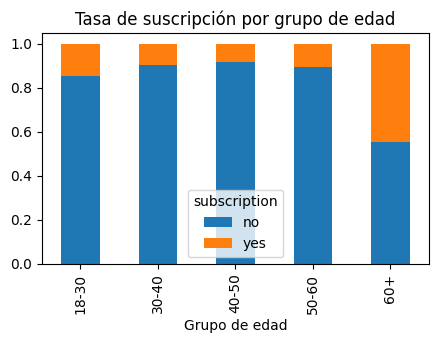

In [73]:
pd.crosstab(bank_final["age_group"], bank_final["subscription"], normalize="index").plot(kind="bar", stacked=True, figsize=(5,3))
plt.title("Tasa de suscripción por grupo de edad")
plt.xlabel("Grupo de edad")
plt.show()

Se observan variaciones en la tasa de suscripción entre los distintos grupos de edad, lo que indica que la edad puede influir en el comportamiento del cliente. Algunos rangos presentan una mayor proporción de contratación. Destaca notablemente el grupo de edad    '+60'

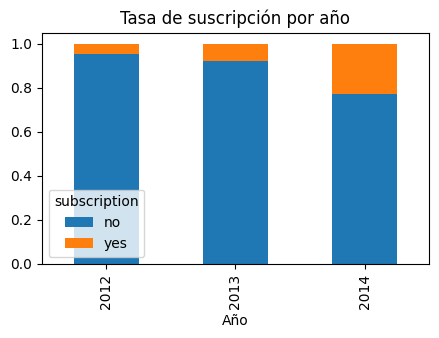

In [72]:
pd.crosstab(bank_final["year"], bank_final["subscription"], normalize="index").plot(kind="bar", stacked=True, figsize=(5,3))
plt.title("Tasa de suscripción por año")
plt.xlabel("Año")
plt.show()

Se identifican variaciones en la tasa de suscripción a lo largo de los años, lo que podría estar relacionado con cambios en el contexto económico o en las estrategias de marketing. A resaltar la comparación entre este gráfico y el gráfico más arriba referente a los clientes captados por año, donde el año 2012 sobresalía con bastante notoriedad sobre los años 2013 y 2014. Lo que hace llamativo a este gráfico es ver cómo el 2012 es el año con menor número de suscripciones a pesar de ser el año con mayor número de clientes captados.

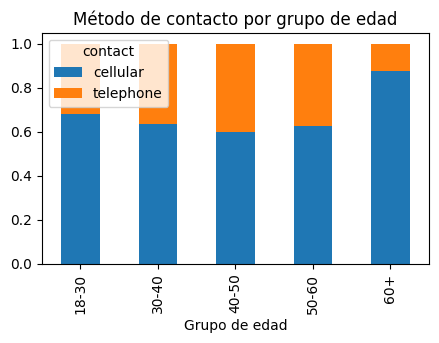

In [69]:
pd.crosstab(bank_final["age_group"], bank_final["contact"], normalize="index").plot(kind="bar", stacked=True, figsize=(5,3))
plt.title("Método de contacto por grupo de edad")
plt.xlabel("Grupo de edad")
plt.show()

El tipo de contacto muestra diferencias en la tasa de suscripción, lo que sugiere que el canal utilizado puede influir en la efectividad de la interacción con el cliente.

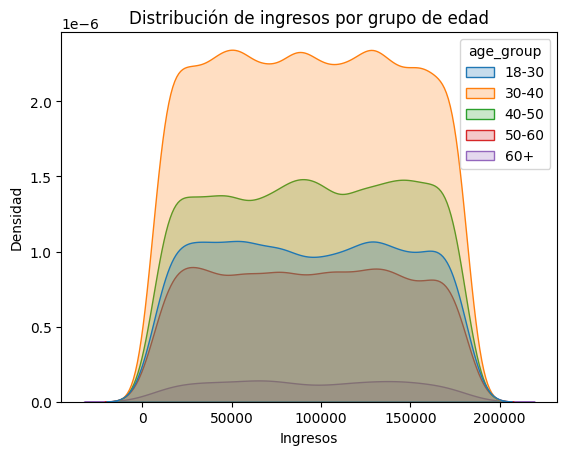

In [70]:
sns.kdeplot(data=bank_final, x="Income", hue="age_group", fill=True,)
plt.title("Distribución de ingresos por grupo de edad")
plt.xlabel("Ingresos")
plt.ylabel("Densidad")
plt.show()

Se observa una tendencia en la que los ingresos varían en función del grupo de edad, alcanzando valores más elevados en grupos intermedios. Esto puede estar relacionado con la experiencia laboral y la estabilidad económica.

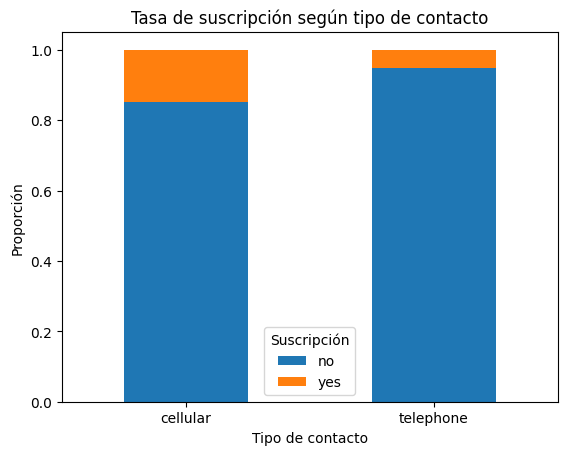

In [ ]:
pd.crosstab(
    bank_final["contact"],
    bank_final["subscription"],
    normalize="index"
).plot(kind="bar", stacked=True)

plt.title("Tasa de suscripción según tipo de contacto")
plt.xlabel("Tipo de contacto")
plt.ylabel("Proporción")
plt.xticks(rotation=0)
plt.legend(title="Suscripción")

plt.show()

Se observa en el gráfico que el método de contacto influye bastante en la suscripción a algún producto o servicio por parte de los clientes. Aquí se puede observar cómo es más probable que se suscriban los clientes contactados a través de teléfono móvil.